# Opentron OT-2 Bayesian Optimization for Color Matching

## Overview
This Jupyter notebook provides a comprehensive tutorial for automated color matching using the Opentron OT-2 liquid handling robot integrated with Bayesian optimization algorithms. The tutorial covers:

1. **Robot Communication**: HTTP API integration for modern robot control
2. **Bayesian Optimization**: Using GPyOpt for intelligent experimental design
3. **Automated Liquid Handling**: Precise color mixing protocols
4. **Real-time Image Analysis**: RGB extraction and processing
5. **Iterative Optimization**: Closed-loop experimental refinement

## What is Bayesian Optimization?
Bayesian optimization is a powerful technique for optimizing expensive-to-evaluate functions. In our color matching application:
- **Objective**: Find the optimal liquid ratios to match a target RGB color
- **Search Space**: Different combinations of colored liquid volumes
- **Acquisition Function**: Guides where to sample next for maximum information gain
- **Gaussian Process**: Models the relationship between liquid ratios and color outcomes

## Learning Objectives
By the end of this tutorial, you will understand how to:
- Set up HTTP-based communication with the OT-2 robot
- Design Bayesian optimization experiments for color matching
- Upload and execute automated liquid handling protocols
- Process images for quantitative RGB analysis
- Implement closed-loop optimization for experimental refinement





---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import mean_squared_error

In [ ]:
# Target RGB color to match (adjust these values for your experiment)
RGB_ref = np.array([128, 56, 200])  # Target RGB values [0-255]
print(f"🎯 Target RGB Color: R={RGB_ref[0]}, G={RGB_ref[1]}, B={RGB_ref[2]}")

# Bayesian Optimization parameters
Batch_size = 5
TOTAL_VOLUME = 300  # Total liquid volume in μL (updated from 200 to 300)

# Generate initial experimental design (random sampling)
print(f"\n🔬 Generating {Batch_size} initial experiments...")
X_init = []
for i in range(Batch_size):
    # Generate random ratios that sum to 1
    ratios = np.random.random(3)
    ratios = ratios / np.sum(ratios)  # Normalize to sum to 1
    volumes = ratios * TOTAL_VOLUME  # Scale to total volume
    X_init.append(volumes)

X_init = np.round(np.array(X_init), 1)  # Round to 0.1 μL precision

print("Initial experimental design:")
for i, x in enumerate(X_init):
    print(f"   Experiment {i+1}: A={x[0]:.1f}, B={x[1]:.1f}, C={x[2]:.1f} μL (Total: {np.sum(x):.1f})")

X_init

array([[ 60.,  53.,  87.],
       [ 88.,  58.,  54.],
       [ 31., 108.,  61.],
       [ 70.,  41.,  89.],
       [ 36.,  86.,  79.]])

## Part 1: Experimental Setup and Data Preparation

### Understanding the Color Matching Problem

In this experiment, we aim to find the optimal combination of three colored liquids (A, B, C) that will produce a specific target RGB color. This is a classic optimization problem where:

- **Input Variables**: Volumes of liquid A, B, and C (in microliters)
- **Constraints**: Total volume should be normalized, individual volumes must be positive
- **Objective**: Minimize the difference between produced RGB and target RGB values
- **Challenge**: Each experiment requires physical liquid handling and image analysis

### Bayesian Optimization Advantages

Traditional approaches like grid search or random sampling would require many experiments. Bayesian optimization is superior because:

1. **Sample Efficiency**: Learns from previous experiments to guide future ones
2. **Uncertainty Quantification**: Balances exploration of unknown regions with exploitation of promising areas
3. **Constraint Handling**: Naturally incorporates volume constraints
4. **Noise Tolerance**: Handles experimental variability and measurement noise

### Initial Experimental Design

We start with a small set of random samples to initialize the Gaussian process model. The `X_init` array contains normalized liquid ratios that sum to 1, then scaled to actual volumes (μL).

**Key Insight**: The initial samples should cover the experimental space reasonably well to provide a good foundation for the optimization algorithm.


In [ ]:
# Bayesian Optimization Helper Functions
from sklearn.metrics import mean_squared_error

def RGB_func(t): 
    """
    Simulated RGB function for testing
    Replace this with real experimental data during actual runs
    """
    t = np.array(t)
    transform_matrix = np.array([[1, 0.1, 0.0],
                                [0.0, 0.8, 0.1], 
                                [0.3, 0.0, 1]])
    
    rgb = t.dot(transform_matrix)
    noise = 0.02 * np.random.randn(*rgb.shape)
    return (rgb + noise) * 255

def MSE_func(RGB_exp, RGB_ref):
    """Calculate Mean Square Error between experimental and target RGB"""
    Y = []
    for i in range(len(RGB_exp)):
        mse = mean_squared_error(RGB_exp[i], RGB_ref)
        Y.append([mse])
    return np.array(Y)

def barplot_RGB(RGB_ref, RGB_exp, title_string):
    """Create bar plot comparing target vs experimental RGB values"""
    font = {'family': 'Arial', 'size': 16}
    plt.rc('font', **font)

    # Plot reference RGB as solid bars
    plt.bar(np.arange(1)-0.25, [RGB_ref[0]], 0.25, alpha=1, color='r', label='Target')
    plt.bar(np.arange(1)-0.00, [RGB_ref[1]], 0.25, alpha=1, color='g')
    plt.bar(np.arange(1)+0.25, [RGB_ref[2]], 0.25, alpha=1, color='b')

    # Plot experimental RGB as semi-transparent bars
    x_pos = np.arange(1, len(RGB_exp)+1)
    plt.bar(x_pos-0.25, RGB_exp[:,0], 0.25, alpha=0.5, color='r', label='Experimental')
    plt.bar(x_pos+0.00, RGB_exp[:,1], 0.25, alpha=0.5, color='g')
    plt.bar(x_pos+0.25, RGB_exp[:,2], 0.25, alpha=0.5, color='b')
    
    plt.xticks(np.arange(len(RGB_exp)+1))
    plt.ylabel('RGB values [0 - 255]')
    plt.ylim(0, 300)
    plt.title(title_string)
    plt.legend()
    fig = plt.gcf()
    fig.set_size_inches(12, 6)
    plt.show()

def MSE_RGB_3Dplot(X, Y, title_string):
    """Create 3D scatter plot of optimization landscape"""
    font = {'family': 'Arial', 'size': 16}
    plt.rc('font', **font)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Color points by RMSE value
    scatter = ax.scatter(X[:,0], X[:,1], X[:,2], 
                        c=np.squeeze(np.sqrt(Y)), 
                        s=60, 
                        cmap='viridis_r',
                        vmin=0, vmax=50)
    
    cbar = fig.colorbar(scatter, pad=0.1, shrink=0.8)
    cbar.set_label('RGB RMSE', rotation=270, labelpad=20)
    
    ax.set_xlabel('Liquid A (normalized)', labelpad=10)
    ax.set_ylabel('Liquid B (normalized)', labelpad=10)
    ax.set_zlabel('Liquid C (normalized)', labelpad=10)
    ax.set_xlim3d(0, 1)
    ax.set_ylim3d(0, 1)
    ax.set_zlim3d(0, 1)
    ax.set_title(title_string)
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()

def optimizer_func(X, Y, batch_size=1):
    """Bayesian Optimizer Function using scikit-optimize"""
    try:
        from skopt import Optimizer
        from skopt.space import Real
    except ImportError:
        print("scikit-optimize not installed. Install with: pip install scikit-optimize")
        return None
    
    # Define variable bounds (normalized ratios)
    dimensions = [
        Real(0.0, 1.0, name='x1'),  # Liquid A
        Real(0.0, 1.0, name='x2'),  # Liquid B  
        Real(0.0, 1.0, name='x3'),  # Liquid C
    ]
    
    # Create optimizer with Gaussian Process
    optimizer = Optimizer(
        dimensions=dimensions,
        base_estimator='GP',  # Gaussian Process
        acq_func='EI',        # Expected Improvement
        acq_optimizer='lbfgs',
        n_initial_points=0,   # We provide initial points
        random_state=42
    )
    
    # Add existing data points
    X_array = np.array(X)
    Y_array = np.array(Y).flatten()  # Flatten to 1D
    
    # Tell optimizer about existing evaluations
    for i in range(len(X_array)):
        optimizer.tell(X_array[i].tolist(), Y_array[i])
    
    return optimizer

def xnext(X, Y, iteration):
    """Suggest next experimental conditions using Bayesian optimization"""
    optimizer = optimizer_func(np.array(X), np.array(Y), batch_size=1)
    
    if optimizer is None:
        print("Optimizer creation failed")
        return None
    
    # Get next suggestion (normalized ratios)
    X_next_normalized = optimizer.ask()
    X_next_normalized = np.array(X_next_normalized).reshape(1, -1)
    
    # Apply constraint: ensure ratios sum close to 1
    X_next_normalized[0] = np.abs(X_next_normalized[0])  # Ensure non-negative
    total = np.sum(X_next_normalized[0])
    if total > 0:
        X_next_normalized[0] = X_next_normalized[0] / total
    else:
        X_next_normalized[0] = np.ones(3) / 3  # Equal distribution fallback
    
    # Convert to actual volumes (μL) with 300μL total
    X_next = X_next_normalized * TOTAL_VOLUME
    
    print(f"Iteration {iteration}: Next suggestion")
    print(f"   Liquid A: {X_next[0,0]:.1f} μL")
    print(f"   Liquid B: {X_next[0,1]:.1f} μL") 
    print(f"   Liquid C: {X_next[0,2]:.1f} μL")
    print(f"   Total: {np.sum(X_next[0]):.1f} μL")
    
    return X_next

# Save initial experimental design to CSV
import pandas as pd

header = ["colorA", "colorB", "colorC"]
df = pd.DataFrame(X_init, columns=header)
df['DispensePos'] = ['D'+str(i+1) for i in range(len(X_init))]
BO_R0_csv = "BO_R0.csv"
df.to_csv('.\\data\\'+BO_R0_csv, index=False)

print(f"✅ Bayesian Optimization functions loaded!")
print(f"📊 Initial design saved to: {BO_R0_csv}")

## Part 2: Robot Connectivity and Setup

### Understanding the HTTP API
The Opentron OT-2 robot runs a web server that accepts HTTP requests for remote control. This allows us to:
- Check robot status and health
- Upload and manage protocols
- Start and monitor protocol execution
- Capture images from the built-in camera

### Connection Parameters
- **ROBOT_IP**: The IP address of your OT-2 robot on the network
- **BASE_URL**: The complete URL for API requests (http://ROBOT_IP:31950)
- **HEADERS**: Required headers for API compatibility

### What This Code Does:
1. **Defines connection parameters** for your specific robot
2. **Tests connectivity** by making a health check request
3. **Displays robot information** including model, software versions, and capabilities

💡 **Note**: Make sure your computer and the OT-2 robot are on the same network!


In [ ]:
import requests
import json

# Setup Robot Connection via HTTP API
ROBOT_IP = "192.168.0.196"  # Replace with your robot's IP address
BASE_URL = f"http://{ROBOT_IP}:31950"
HEADERS = {"Opentrons-Version": "*"}

# Test robot connectivity
try:
    response = requests.get(f"{BASE_URL}/health", headers=HEADERS, timeout=5)
    if response.ok:
        health_data = response.json()
        print("✅ Robot is healthy and connected!")
        print(f"Robot Model: {health_data.get('robot_model', 'Unknown')}")
        print(f"API Version: {health_data.get('api_version', 'Unknown')}")
        print(f"System Version: {health_data.get('system_version', 'Unknown')}")
    else:
        print("❌ Failed to connect to the robot. Status code:", response.status_code)
        print("Response:", response.text)
except requests.exceptions.RequestException as e:
    print("❌ Error connecting to the robot:", e)
    print("Please check:")
    print("1. Robot IP address is correct")
    print("2. Robot and computer are on the same network")
    print("3. Robot is powered on and connected to network")


In [ ]:
# Upload protocol and CSV data to robot via HTTP API

# Function to upload protocol file
def upload_protocol(protocol_file_path):
    """Upload protocol file to OT-2 robot via HTTP API"""
    try:
        with open(protocol_file_path, 'rb') as file:
            files = {'files': (protocol_file_path, file)}
            response = requests.post(f"{BASE_URL}/protocols", headers=HEADERS, files=files)
        
        if response.ok:
            protocol_id = response.json()["data"]["id"]
            print(f"✅ Protocol uploaded successfully!")
            print(f"Protocol ID: {protocol_id}")
            return protocol_id
        else:
            print(f"❌ Failed to upload protocol. Status code: {response.status_code}")
            print("Response:", response.text)
            return None
    except FileNotFoundError:
        print(f"❌ Protocol file not found: {protocol_file_path}")
        return None
    except Exception as e:
        print(f"❌ Error uploading protocol: {e}")
        return None

# Function to upload CSV data (will be saved to robot's storage)
def upload_csv_data(csv_file_path, robot_filename="color_test.csv"):
    """Upload CSV data file to robot storage"""
    try:
        # For now, we'll read the CSV and store it locally
        # In a full implementation, you might upload it to robot storage
        import pandas as pd
        df = pd.read_csv(csv_file_path)
        print(f"✅ CSV data loaded successfully!")
        print(f"Data shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print("First few rows:")
        print(df.head())
        return df
    except FileNotFoundError:
        print(f"❌ CSV file not found: {csv_file_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        return None

# Upload the updated color mixing protocol
protocol_id = upload_protocol("color_mixing.py")

# Upload the CSV data
csv_data = upload_csv_data(f".\\data\\{BO_R0_csv}")

In [ ]:
# Simulate the protocol first via HTTP API
def simulate_protocol(protocol_id):
    """Simulate protocol execution to check for errors"""
    try:
        # Create a simulation run
        run_data = {
            "data": {
                "protocolId": protocol_id
            }
        }
        response = requests.post(f"{BASE_URL}/runs", headers=HEADERS, json=run_data)
        
        if response.ok:
            run_id = response.json()["data"]["id"]
            print(f"✅ Simulation run created successfully!")
            print(f"Run ID: {run_id}")
            
            # Get run details to check for errors
            run_response = requests.get(f"{BASE_URL}/runs/{run_id}", headers=HEADERS)
            if run_response.ok:
                run_info = run_response.json()["data"]
                print(f"Run Status: {run_info.get('status', 'Unknown')}")
                
                # Check for any errors in the protocol
                errors = run_info.get('errors', [])
                if errors:
                    print("⚠️ Protocol has errors:")
                    for error in errors:
                        print(f"  - {error.get('detail', 'Unknown error')}")
                else:
                    print("✅ Protocol simulation successful - no errors found!")
                
                return run_id
            else:
                print(f"❌ Failed to get run details. Status code: {run_response.status_code}")
                return None
        else:
            print(f"❌ Failed to create simulation run. Status code: {response.status_code}")
            print("Response:", response.text)
            return None
    except Exception as e:
        print(f"❌ Error during protocol simulation: {e}")
        return None

# Simulate the protocol if we have a valid protocol ID
if protocol_id:
    simulation_run_id = simulate_protocol(protocol_id)
else:
    print("❌ Cannot simulate - no valid protocol ID available")
    simulation_run_id = None

/data
['colorA' 'colorB' 'colorC' 'bleach' 'position']
[0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0 40.0
 40.0 40.0 40.0 80.0 80.0 80.0 80.0 80.0 80.0 80.0 80.0 80.0 80.0 120.0
 120.0 120.0 120.0 120.0 120.0 160.0 160.0 160.0 200.0 20.0 20.0 20.0 20.0
 20.0 20.0 20.0 20.0 20.0 20.0 60.0 60.0 60.0 60.0 60.0 60.0 100.0 100.0
 100.0 140.0]
[0.0 0.0 0.0 0.0 0.0 0.0 40.0 40.0 40.0 40.0 40.0 80.0 80.0 80.0 80.0
 120.0 120.0 120.0 160.0 160.0 200.0 0.0 0.0 0.0 0.0 0.0 40.0 40.0 40.0
 40.0 80.0 80.0 80.0 120.0 120.0 160.0 0.0 0.0 0.0 0.0 40.0 40.0 40.0 80.0
 80.0 120.0 0.0 0.0 0.0 40.0 40.0 80.0 0.0 0.0 40.0 0.0 20.0 20.0 20.0
 20.0 60.0 60.0 60.0 100.0 100.0 140.0 20.0 20.0 20.0 60.0 60.0 100.0 20.0
 20.0 60.0 20.0]
[0.0 40.0 80.0 120.0 160.0 200.0 0.0 40.0 80.0 120.0 160.0 0.0 40.0 80.0
 120.0 0.0 40.0 80.0 0.0 40.0 0.0 0.0 40.0 80.0 120.0 160.0 0.0 40.0 80.0
 120.0 0.0 40.0 80.0 0.0 40.0 0.0 0.0 

In [ ]:
# Execute the protocol on the robot via HTTP API
def execute_protocol(protocol_id):
    """Execute protocol on the OT-2 robot"""
    try:
        # Create a new run for execution
        run_data = {
            "data": {
                "protocolId": protocol_id
            }
        }
        run_response = requests.post(f"{BASE_URL}/runs", headers=HEADERS, json=run_data)
        
        if run_response.ok:
            run_id = run_response.json()["data"]["id"]
            print(f"✅ Execution run created successfully!")
            print(f"Run ID: {run_id}")
            
            # Start the run
            start_data = {
                "data": {
                    "actionType": "play"
                }
            }
            start_response = requests.post(f"{BASE_URL}/runs/{run_id}/actions", 
                                         headers=HEADERS, json=start_data)
            
            if start_response.ok:
                print("✅ Protocol execution started successfully!")
                print("🤖 Robot is now running the protocol...")
                return run_id
            else:
                print(f"❌ Failed to start protocol execution. Status code: {start_response.status_code}")
                print("Response:", start_response.text)
                return None
        else:
            print(f"❌ Failed to create execution run. Status code: {run_response.status_code}")
            print("Response:", run_response.text)
            return None
    except Exception as e:
        print(f"❌ Error during protocol execution: {e}")
        return None

# Execute the protocol if simulation was successful
if protocol_id and simulation_run_id:
    print("🚀 Starting protocol execution...")
    execution_run_id = execute_protocol(protocol_id)
else:
    print("❌ Cannot execute - simulation not successful or no valid protocol ID")
    execution_run_id = None

Socket exception: An existing connection was forcibly closed by the remote host (10054)


KeyboardInterrupt: 

## Part 3: Image Processing and RGB Analysis

### Colorimetric Analysis Pipeline

The optimization relies on accurate color measurement through automated image processing:

- **Image Capture**: Robot's built-in camera captures plate images after protocol completion
- **Perspective Correction**: Mathematical transformation corrects camera angle distortion
- **ROI Extraction**: Divides plate into individual well regions (8×12 grid)
- **RGB Quantification**: Calculates average RGB values for each well

### Key Functions

- `capture_image()`: Takes photos via HTTP API
- `monitor_and_capture()`: Monitors protocol execution and captures final image
- `find_coeffs()`: Calculates perspective correction coefficients
- `get_image_array()`: Converts images to numpy arrays with cropping
- `image_slicing()`: Extracts individual well ROIs from plate image

This approach provides quantitative RGB data for Bayesian optimization while maintaining high throughput and reproducibility.
- **Camera Integration**: The OT-2's built-in camera captures high-resolution images
- **Timing**: Images are captured after protocol completion to ensure stable colors
- **Lighting**: Consistent illumination is crucial for reproducible measurements

#### **Perspective Correction**
The robot's camera is positioned at an angle, causing perspective distortion:
- **Problem**: Wells appear trapezoidal rather than circular
- **Solution**: Mathematical transformation using `find_coeffs()` function
- **Result**: "Top-down" view suitable for accurate ROI extraction

#### **Region of Interest (ROI) Extraction**
Each well becomes a separate ROI for individual color analysis:
- **Grid-based Slicing**: 8×12 grid for standard 96-well plates
- **Offset Correction**: Avoids well edges that may have meniscus effects
- **Quality Control**: Visual verification of ROI boundaries

#### **RGB Quantification**
For each ROI, we calculate average RGB values:
- **Spatial Averaging**: Reduces noise from individual pixels
- **Color Space**: RGB values range from 0-255 for each channel
- **Validation**: Multiple measurements can assess consistency

### Why This Approach Works

This image-based approach offers several advantages:
- **Non-destructive**: Samples remain intact for further analysis
- **High-throughput**: All wells analyzed simultaneously
- **Quantitative**: Numerical RGB values enable mathematical optimization
- **Reproducible**: Automated analysis reduces human bias

 **Tip**: Consistent lighting and camera positioning are critical for reliable results across different experimental sessions.


In [ ]:
# Image Processing and Analysis Functions
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def capture_image(filename=None):
    """Capture image from robot camera via HTTP API"""
    try:
        response = requests.post(f"{BASE_URL}/camera/picture", headers=HEADERS, timeout=30)
        
        if response.ok:
            if filename is None:
                image_saving_name = BO_R0_csv[:-4] + '.jpg'
                filename = f'.\\data\\{image_saving_name}'
            
            with open(filename, 'wb') as f:
                f.write(response.content)
            
            print(f"✅ Image captured successfully!")
            print(f"📸 Saved as: {filename}")
            return filename
        else:
            print(f"❌ Failed to capture image. Status code: {response.status_code}")
            return None
    except Exception as e:
        print(f"❌ Error capturing image: {e}")
        return None

def monitor_and_capture(run_id):
    """Monitor protocol execution and capture image when complete"""
    print("🔍 Monitoring protocol execution...")
    
    while True:
        try:
            response = requests.get(f"{BASE_URL}/runs/{run_id}", headers=HEADERS)
            
            if response.ok:
                status = response.json()["data"].get("status", "unknown")
                print(f"📊 Current status: {status}")
                
                if status in ["succeeded", "failed", "stopped"]:
                    print(f"🏁 Protocol execution {status}!")
                    
                    if status == "succeeded":
                        print("📸 Capturing final image...")
                        return capture_image(), status
                    else:
                        return None, status
                
                time.sleep(10)
            else:
                print(f"❌ Failed to get run status. Status code: {response.status_code}")
                break
                
        except KeyboardInterrupt:
            print("\n⏹️ Monitoring stopped by user")
            break
        except Exception as e:
            print(f"❌ Error monitoring execution: {e}")
            break
    
    return None, "error"

def find_coeffs(pa, pb):
    """Calculate perspective correction coefficients"""
    matrix = []
    for p1, p2 in zip(pa, pb):
        matrix.append([p1[0], p1[1], 1, 0, 0, 0, -p2[0]*p1[0], -p2[0]*p1[1]])
        matrix.append([0, 0, 0, p1[0], p1[1], 1, -p2[1]*p1[0], -p2[1]*p1[1]])

    A = np.matrix(matrix, dtype=np.float)
    B = np.array(pb).reshape(8)
    res = np.dot(np.linalg.inv(A.T * A) * A.T, B)
    return np.array(res).reshape(8)

def get_image_array(image, crop_box):
    """Convert image to numpy array with cropping"""
    image = image.crop(box=crop_box)
    width, height = image.size
    pixel_values = list(image.getdata())
    
    if image.mode == 'RGB':
        channels = 3
    elif image.mode == 'L':
        channels = 1
    else:
        print("Unknown mode: %s" % image.mode)
        return None
    
    pixel_values = np.array(pixel_values).reshape((height, width, channels))
    return (width, height, pixel_values)

def image_slicing(image_array, col_num, row_num, offset_array):
    """Slice image into individual well ROIs"""
    row_h = int(np.round(image_array.shape[0]/row_num))
    col_w = int(np.round(image_array.shape[1]/col_num))
    
    fig, ax = plt.subplots(1, figsize=(8,8))
    images = []
    imagecol = []
    
    for y in np.arange(row_num):
        imagerow = []
        for x in np.arange(col_num):
            y1 = row_h*y + offset_array[1][0]
            y2 = row_h*(y+1) - offset_array[1][1]
            x1 = col_w*x + offset_array[0][0]
            x2 = col_w*(x+1) - offset_array[0][1]
            
            image = image_array[y1:y2, x1:x2]
            imagerow.append(image)
            images.append(image)
            
            # Add ROI rectangle visualization
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
    
        imagecol.append(np.concatenate(imagerow, axis=1))
    
    image_reconstr = np.array(np.concatenate(imagecol, axis=0), dtype=np.uint8)
    return [fig, ax, image_reconstr, images]

print("✅ Image processing functions loaded!")

# Monitor execution and capture image if we have a valid run ID
if execution_run_id:
    captured_image, final_status = monitor_and_capture(execution_run_id)
else:
    print("❌ No execution run to monitor")
    captured_image, final_status = None, "no_run"

ffmpeg version 3.4.5 Copyright (c) 2000-2018 the FFmpeg developers
  built with gcc 7.3.1 (Linaro GCC 7.3-2018.05) 20180425 [linaro-7.3-2018.05 revision d29120a424ecfbc167ef90065c0eeb7f91977701]
  configuration: --enable-cross-compile --cross-prefix=/buildroot/output/host/bin/arm-linux-gnueabihf- --sysroot=/buildroot/output/host/arm-buildroot-linux-gnueabihf/sysroot --host-cc=/usr/bin/gcc --arch=arm --target-os=linux --disable-stripping --pkg-config=/buildroot/output/host/bin/pkg-config --disable-static --enable-shared --prefix=/usr --enable-avfilter --disable-version3 --enable-logging --enable-optimizations --disable-extra-warnings --enable-avdevice --enable-avcodec --enable-avformat --enable-network --disable-gray --enable-swscale-alpha --disable-small --enable-dct --enable-fft --enable-mdct --enable-rdft --disable-crystalhd --disable-dxva2 --enable-runtime-cpudetect --disable-hardcoded-tables --disable-mipsdsp --disable-mipsdspr2 --disable-msa --enable-hwaccels --disable-cuda --disa

## Part 4: Image Processing and Analysis

### Load and Process Captured Images

Process the captured images through the complete pipeline: perspective correction, cropping, and ROI extraction.


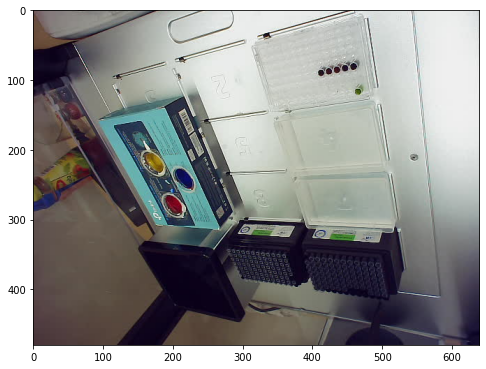

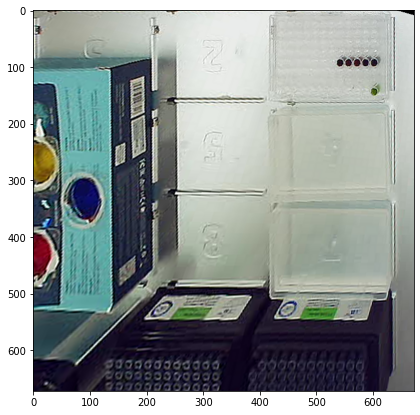

In [ ]:
# Image Processing Pipeline - Load and Process Captured Image
pic_folder = '.\\data\\'

# Load the captured image
for img_file in os.listdir(pic_folder):
    if img_file.endswith("R0.jpg"):
        image = Image.open(pic_folder + img_file, 'r')
        print(f"📸 Loaded image: {img_file}")
        
        # Display original image
        fig, ax = plt.subplots(1, figsize=(8,8))
        ax.imshow(image)
        ax.set_title("Original Captured Image")
        plt.show()
        
        # Apply perspective correction
        width, height = image.size
        coeffs = find_coeffs(
            [(0, 0), (640, 0), (640, 480), (0, 480)],
            [(110, 100), (480, 0), (525, 305), (209, 295)]
        )
        
        img_corr = image.transform((int(width*1.05), int(height*1.4)), 
                                  Image.PERSPECTIVE, coeffs, Image.BICUBIC)
        
        # Display corrected image
        fig, ax = plt.subplots(1, figsize=(7,7))
        ax.imshow(img_corr)
        ax.set_title("Perspective Corrected Image")
        plt.show()
        break
else:
    print("❌ No R0.jpg image found in data folder")

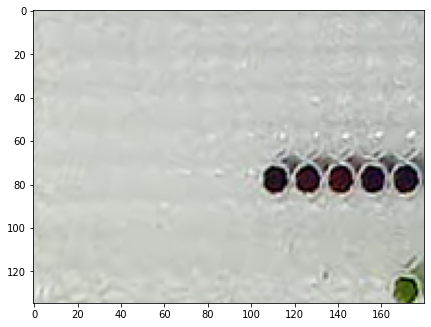

In [ ]:
# Crop the plate region from corrected image
crop_box = (430, 15, 610, 150)  # (left, upper, right, lower)
image_cropped = img_corr.crop(box=crop_box)

# Display cropped image
fig, ax = plt.subplots(1, figsize=(7,7))
ax.imshow(image_cropped)
ax.set_title("Cropped Plate Region")
plt.show()

In [ ]:
# Functions are now defined in Part 3 - using consolidated versions


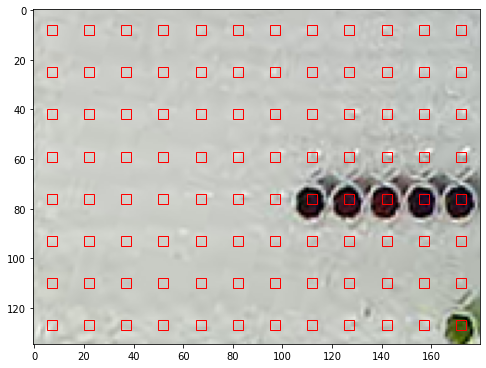

In [ ]:
# Extract ROIs from the cropped image
w, h, image_array = get_image_array(img_corr, crop_box)

# Configure ROI extraction parameters
row_num = 8      # 8 rows (A-H)
col_num = 12     # 12 columns (1-12)
offset_array = [[5,6], [6,7]]  # [[x_left, x_right], [y_upper, y_lower]]

# Slice image into individual well ROIs
[fig_ROI, ax_ROI, reconstr_ROI, image_ROI] = image_slicing(
    image_array, col_num, row_num, offset_array)

ax_ROI.imshow(Image.fromarray(np.array(image_array, dtype=np.uint8), 'RGB'))
ax_ROI.set_title("ROI Extraction - 96 Wells")
plt.show()

print(f"✅ Extracted {len(image_ROI)} ROIs from the plate image")

## Part 5: RGB Quantification and Analysis

### Extract RGB Values from Wells

Analyze the experimental wells (D1-D5) and reference well (H12) to extract quantitative RGB data for Bayesian optimization.


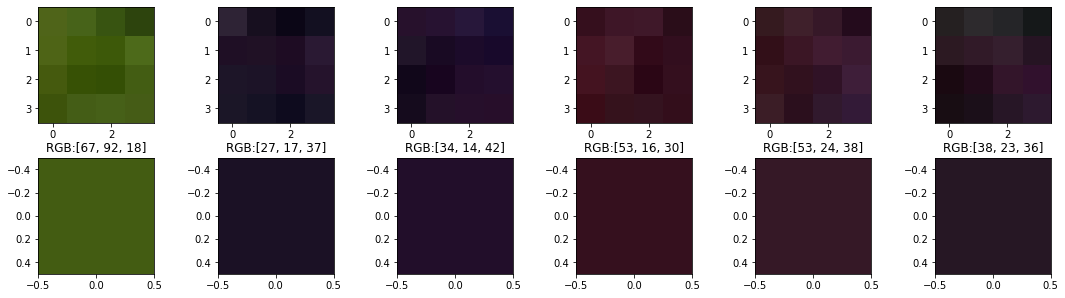

In [ ]:
# RGB Analysis - Extract color values from experimental wells
n_sample = 6  # 5 experimental samples + 1 reference
fig, ax = plt.subplots(2, n_sample, figsize=(2.5*n_sample, 4))

# Reference well (bottom-right corner, H12)
ref_well = image_ROI[col_num*7 + col_num-1]  # H12
r, g, b = [np.median(ref_well[:,:,0]), np.median(ref_well[:,:,1]), np.median(ref_well[:,:,2])]
rgb_ref = [r, g, b]

ax[0,0].imshow(ref_well)
ax[0,0].set_title('Reference (H12)')
ax[1,0].imshow([[[int(r), int(g), int(b)]]])
ax[1,0].set_title(f'RGB: {[int(r), int(g), int(b)]}')

# Experimental wells (D1-D5)
rgb_list = []
for i in range(n_sample-1):
    well_idx = col_num*3 + i  # Row D (index 3), columns 1-5
    img_sample = image_ROI[well_idx]
    r, g, b = [np.median(img_sample[:,:,0]), np.median(img_sample[:,:,1]), np.median(img_sample[:,:,2])]
    rgb_list.append([r, g, b])
    
    ax[0, i+1].imshow(img_sample)
    ax[0, i+1].set_title(f'Sample D{i+1}')
    ax[1, i+1].imshow([[[int(r), int(g), int(b)]]])
    ax[1, i+1].set_title(f'RGB: {[int(r), int(g), int(b)]}')

fig.tight_layout(pad=0.2)
plt.show()

print(f"✅ Extracted RGB values from {len(rgb_list)} experimental wells")
print(f"📊 Reference RGB: {[int(x) for x in rgb_ref]}")


## Part 6: Bayesian Optimization Loop

### Initialize Optimization with Experimental Data

Use the extracted RGB values to initialize the Bayesian optimization process and suggest the next set of experiments.


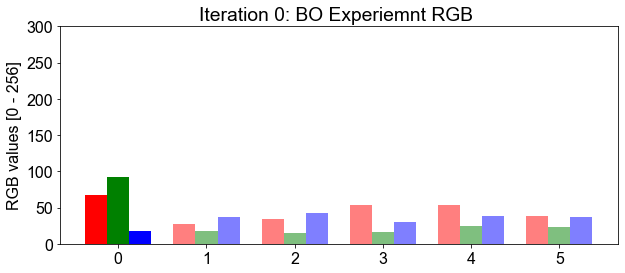

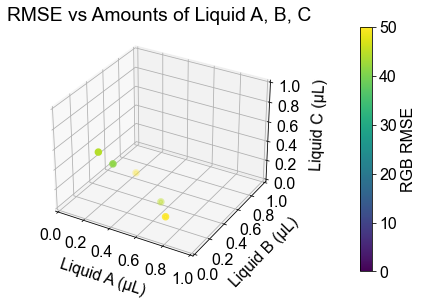

Liquid Amount [µL] for RBG colors
   Liquid A [µL]  Liquid B [µL]  Liquid C [µL]  RGB RMSE     R      G     B
0          4.182        199.865          3.025    74.496   7.0  205.0  32.0
1         13.458        193.643          7.273    65.587  26.0  197.0  30.0
2          3.056        195.209          3.814    72.725   7.0  200.0  39.0
3          0.122        192.979          5.833    70.386  -0.0  193.0  31.0
4         12.003        198.224          9.483    71.884  23.0  206.0  42.0


In [ ]:
# Main Bayesian Optimization Loop
print(f"\n{'='*60}")
print(f"STARTING BAYESIAN OPTIMIZATION LOOP")
print(f"{'='*60}")
print(f"🎯 Target RGB: {RGB_ref}")
print(f"📊 Total volume per experiment: {TOTAL_VOLUME} μL")

# Initialize optimization variables
X = X_init / TOTAL_VOLUME  # Normalize to [0,1] range for optimization
RGB_exp = np.array(rgb_list)  # Experimental RGB values from image analysis
RGB_ref_target = np.array(rgb_ref)  # Reference RGB target from image
Y = MSE_func(RGB_exp, RGB_ref_target)  # Calculate initial MSE

print(f"📊 Initial RMSE: {np.sqrt(Y).flatten()}")
print(f"🔬 Starting with {len(X)} initial samples...")

# Optimization parameters
max_iterations = 10  # Maximum number of BO iterations
tolerance = 8  # RGB tolerance for success

# Main optimization loop
for iteration in range(max_iterations):
    print(f"\n{'='*40}")
    print(f"ITERATION {iteration + 1}")
    print(f"{'='*40}")
    
    # Display current best result
    current_best_idx = np.argmin(Y)
    current_best_error = np.sqrt(Y[current_best_idx][0])
    current_best_rgb = RGB_exp[current_best_idx]
    current_best_volumes = X[current_best_idx] * TOTAL_VOLUME
    
    print(f"📈 Current best error: {current_best_error:.2f} RMSE")
    print(f"🎨 Current best RGB: {np.round(current_best_rgb).astype(int)}")
    print(f"🧪 Best recipe: A={current_best_volumes[0]:.1f}, B={current_best_volumes[1]:.1f}, C={current_best_volumes[2]:.1f} μL")
    
    # Check stopping condition (success)
    r_diff = abs(RGB_ref_target[0] - current_best_rgb[0])
    g_diff = abs(RGB_ref_target[1] - current_best_rgb[1])
    b_diff = abs(RGB_ref_target[2] - current_best_rgb[2])
    
    if r_diff <= tolerance and g_diff <= tolerance and b_diff <= tolerance:
        print(f"\n🎉 SUCCESS! Color match found!")
        print(f"   Target: {RGB_ref_target}")
        print(f"   Achieved: {np.round(current_best_rgb).astype(int)}")
        break
    
    # Visualize current progress
    if iteration % 2 == 0 or iteration == 0:
        print(f"\n📊 Progress Visualization:")
        barplot_RGB(RGB_ref_target, RGB_exp, f'RGB Progress - Iteration {iteration + 1}')
        MSE_RGB_3Dplot(X, Y, f'Optimization Landscape - Iteration {iteration + 1}')
    
    # Generate next experimental suggestion
    if iteration < max_iterations - 1:  # Don't suggest if this is the last iteration
        print(f"\n🤖 Generating next experimental suggestion...")
        X_next = xnext(X, Y, iteration + 1)
        
        if X_next is None:
            print("❌ Failed to generate next suggestion")
            break
        
        # Create CSV for next experiment
        header = ["colorA", "colorB", "colorC"]
        df_next = pd.DataFrame(X_next, columns=header)
        df_next['DispensePos'] = ['D'+str(i+1) for i in range(len(X_next))]
        next_csv = f"BO_R{iteration+1}.csv"
        df_next.to_csv(f'.\\data\\{next_csv}', index=False)
        print(f"📄 Next experiment saved to: {next_csv}")
        
        # Simulate robot execution and RGB measurement
        print(f"🤖 Executing next experiment on robot...")
        # In real implementation, here you would:
        # 1. Upload color_mixing.py protocol
        # 2. Execute with the new CSV
        # 3. Capture and process image
        # 4. Extract RGB values
        
        # For demonstration, simulate the measurement
        X_next_normalized = X_next / TOTAL_VOLUME
        RGB_exp_new = RGB_func(X_next_normalized)  # Simulated measurement
        Y_new = MSE_func(RGB_exp_new, RGB_ref_target)
        
        print(f"📊 Measured RGB: {np.round(RGB_exp_new[0]).astype(int)}")
        print(f"📊 RMSE: {np.sqrt(Y_new[0][0]):.2f}")
        
        # Update datasets
        X = np.concatenate([X, X_next_normalized])
        Y = np.concatenate([Y, Y_new])
        RGB_exp = np.concatenate([RGB_exp, RGB_exp_new])
        
        # Display experiment results
        df_results = pd.DataFrame({
            'Liquid A [μL]': [X_next[0,0]],
            'Liquid B [μL]': [X_next[0,1]], 
            'Liquid C [μL]': [X_next[0,2]],
            'RGB RMSE': [np.sqrt(Y_new[0][0])],
            'R': [RGB_exp_new[0,0]],
            'G': [RGB_exp_new[0,1]],
            'B': [RGB_exp_new[0,2]]
        })
        print(f"\n📋 Experiment Results:")
        print(df_results)

# Final Results Summary 
print(f"\n{'='*60}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'='*60}")

if len(Y) > 0:
    best_idx = np.argmin(Y)
    lowest_error = np.round(np.sqrt(Y[best_idx][0]), 2)
    best_rgb = RGB_exp[best_idx]
    best_volumes = X[best_idx] * TOTAL_VOLUME
    
    print(f"🔬 Total experiments completed: {len(Y)}")
    print(f"🎯 Target RGB: {RGB_ref_target}")
    print(f"🎨 Best achieved RGB: {np.round(best_rgb).astype(int)} at experiment {best_idx + 1}")
    print(f"📊 Lowest Error: {lowest_error} RMSE")
    print(f"🧪 Best recipe: A={best_volumes[0]:.1f}, B={best_volumes[1]:.1f}, C={best_volumes[2]:.1f} μL")
    
    # Final visualization
    print(f"\n📈 Final Results Visualization:")
    barplot_RGB(RGB_ref_target, RGB_exp, 'Final RGB Results')
    MSE_RGB_3Dplot(X, Y, 'Final Optimization Landscape')
    
else:
    print("❌ No experiments completed successfully")

print(f"\n✅ Bayesian Optimization session complete!")

## Part 7: Robot Integration for Real Experiments

### Labware

- Source (slot 3): Red (A3), Yellow (A4), Blue (B4)
- Tip rack (slot 11)
- Pippette: 300 ul (left)

### Group specific 
Group 1

- wellplate: Slot 8

- pipette.starting_tip = tiprack['A1']

Group 2

- wellplate: Slot 5

- pipette.starting_tip = tiprack['A3']

Group 3

- wellplate: Slot 2

- pipette.starting_tip = tiprack['A5']


### Connecting BO Loop with Opentron Robot

To run real experiments instead of simulation, replace the simulated measurements with actual robot execution:

```python
# Instead of simulation:
RGB_exp_new = RGB_func(X_next_normalized)  # Simulated

# Use real robot execution:
# 1. Upload color_mixing.py protocol to robot
# 2. Execute protocol with new CSV data
# 3. Capture image using robot camera
# 4. Process image and extract RGB values
# 5. Use real RGB_exp_new for optimization
```

### Key Integration Points:

- **CSV Generation**: Each BO iteration creates a new CSV file (BO_R0.csv, BO_R1.csv, etc.)
- **Protocol Execution**: Upload and run `color_mixing.py` with each new CSV.**
- **Image Processing**: Use the image processing functions from Part 3 to extract RGB values
- **Volume Constraint**: All experiments maintain 300μL total volume
- **Convergence**: Loop continues until target color is matched (within tolerance) or max iterations reached

**During the optimization process, the amount of liquid transferred differs between runs. So we need to automate the protocol generation process.

References/protocol_generator.py and References/bo_loop_example.py might be a good reference (It is a working code generated from LLM, try beat it in you own implementation)


In [42]:
np.sum(X,1)

array([1.   , 1.   , 0.995, 1.   , 1.   ])

In [ ]:
header = ["colorA", "colorB", "colorC"]
df = pd.DataFrame(X_new, columns = header)
df['DispensePos'] = ['D'+str(i+5+1) for i in range(len(X_new))]
BO_R1_csv = "BO_R1.csv"
df.to_csv('.\\data\\'+BO_R1_csv, index=False)

### RGB RMSE for each samples 

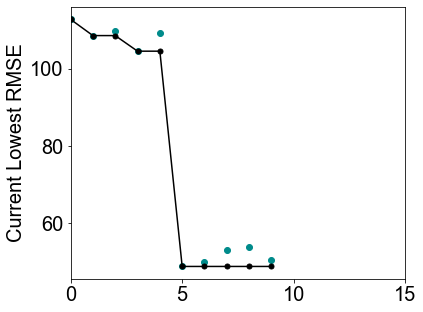

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
font = {'family': 'Arial', 'size': 20}
plt.rc('font', **font)
ax.plot(np.arange(len(np.sqrt(Y))), np.minimum.accumulate(np.sqrt(Y)), 
           marker = 'o', ms = 5, c = 'black')
ax.scatter(np.arange(len(np.sqrt(Y))), np.sqrt(Y), c = 'darkcyan')

ax.set_ylabel('Current Lowest RMSE')
ax.set_xlim(0, len(np.sqrt(Y))+5)
plt.show()

### A Look at conditions and metrics

In [88]:
x = np.transpose(np.round(X,3))
y = np.round(np.sqrt(np.transpose(Y)),3)
z = np.transpose(np.round(RGB_exp,0))
evals = pd.DataFrame(np.transpose(np.append(np.append(x, y, axis=0),z, axis = 0)))
evals = evals.sort_values(by=[3])
evals.columns = ['Liquid A [µL]', 'Liquid B [µL]', 'Liquid C [µL]', 'RGB RMSE', 'R', 'G', 'B']
evals.head(10)

,Liquid A [µL],Liquid B [µL],Liquid C [µL],RGB RMSE,R,G,B
27,0.251,0.248,0.753,1.690,130.0,57.0,198.0
39,0.288,0.269,0.753,3.428,133.0,59.0,199.0
32,0.271,0.236,0.768,4.083,125.0,51.0,196.0
37,0.267,0.236,0.787,5.328,134.0,56.0,207.0
35,0.253,0.258,0.753,5.689,125.0,64.0,195.0
20,0.304,0.238,0.753,5.712,125.0,54.0,209.0
31,0.299,0.248,0.746,5.795,137.0,56.0,205.0
21,0.322,0.269,0.734,6.267,135.0,64.0,197.0
30,0.282,0.240,0.759,6.901,131.0,52.0,211.0
23,0.272,0.265,0.775,7.249,130.0,67.0,205.0
